In [11]:
import pandas as pd
import numpy as np
import json
import pickle
import os
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import tf2onnx

warnings.filterwarnings('ignore')

# Configuration

In [12]:
# --- 1. CONFIGURATION ---
# OUTPUT_DIR = '../../model_outputs/massive'
# DATASET_PATH = '../../dataset/massive_dataset_sapi_lstm.csv' 

OUTPUT_DIR = '../../model_outputs'
DATASET_PATH = '../../dataset/dataset_sapi_lstm.csv' 
WINDOW = 30  
TARGET = 'jumlah_susu'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Output folder ready: {OUTPUT_DIR}")

✅ Output folder ready: ../../model_outputs


# Data Prep

In [13]:
# --- 2. DATA PREPARATION ---'
# print("Current directory:", os.getcwd())
df = pd.read_csv(DATASET_PATH)

# Drop columns not needed for the math, ignoring errors if they don't exist
DROP_COLS = ['nama_sapi', 'pemerahan_id', 'tgl_lahir', 'pemerah']
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')

# Sort chronologically per cow
df['tgl_pemerahan'] = pd.to_datetime(df['tgl_pemerahan'], errors='coerce')
df = df.sort_values(['sapi_id', 'tgl_pemerahan']).reset_index(drop=True)

# Extract Time Features
df['bulan'] = df['tgl_pemerahan'].dt.month
df['hari_minggu'] = df['tgl_pemerahan'].dt.dayofweek
df['jam'] = df['tgl_pemerahan'].dt.hour

# Robust Encoding

In [14]:
CATEGORICAL_COLS = ['jenis_sapi', 'jenis_pakan', 'kondisi_sapi', 'status_reproduksi']
encoders = {}

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    
    df[col] = df[col].astype(str)
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"Encoded {col}: {list(le.classes_)}")

df_final = df.drop(columns=CATEGORICAL_COLS + ['tgl_pemerahan'])

Encoded jenis_sapi: ['Perah jenis FH', 'Perah perabakan FH', 'Perah peranakan FH', 'perah jenis FH', 'perah peranakan FH', 'sapi perah jenis FH']
Encoded jenis_pakan: ['Campuran', 'Konsentrat', 'Rumput']
Encoded kondisi_sapi: ['Sehat']
Encoded status_reproduksi: ['Hamil', 'Laktasi']


# LTSM Sequence (Windowing)

In [ ]:
FEATURE_COLS = [c for c in df_final.columns if c not in [TARGET, 'sapi_id']]
n_features = len(FEATURE_COLS)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

all_X, all_y = [], []

for cow_id, group in df_final.groupby('sapi_id'):
    group = group.reset_index(drop=True)
    if len(group) <= WINDOW:
        print(f"⚠️ Skipping cow {cow_id}: Only {len(group)} records (needs > {WINDOW})")
        continue # Skip cows that don't have enough history

    features = group[FEATURE_COLS].values.astype(float)
    target = group[TARGET].values.astype(float).reshape(-1, 1)

    for i in range(WINDOW, len(group)):
        all_X.append(features[i-WINDOW:i])
        all_y.append(target[i])

all_X = np.array(all_X, dtype=np.float32)
all_y = np.array(all_y, dtype=np.float32)

# --- SAFETY CHECK TO PREVENT CRASH ---
if len(all_X) == 0:
    raise ValueError(f"❌ Error: No sequences generated! The dataset is too small for a WINDOW size of {WINDOW}.")

all_X_scaled = scaler_X.fit_transform(all_X.reshape(-1, n_features)).reshape(-1, WINDOW, n_features)
all_y_scaled = scaler_y.fit_transform(all_y)

print(f"\n✅ Total Sequences generated: {len(all_X_scaled)}")

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

# Training

In [6]:
X_train, X_test, y_train, y_test = train_test_split(all_X_scaled, all_y_scaled, test_size=0.2, random_state=42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, n_features)),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("\n🚀 Training started...")
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1, verbose=1)


🚀 Training started...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0632 - mae: 0.2039 - val_loss: 0.0466 - val_mae: 0.1898
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0496 - mae: 0.1834 - val_loss: 0.0383 - val_mae: 0.1693
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0443 - mae: 0.1715 - val_loss: 0.0436 - val_mae: 0.1824
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0408 - mae: 0.1651 - val_loss: 0.0369 - val_mae: 0.1660
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0404 - mae: 0.1591 - val_loss: 0.0541 - val_mae: 0.2054
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0430 - mae: 0.1679 - val_loss: 0.0373 - val_mae: 0.1675
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0461 - mae: 0.1748 - val_loss: 0.0485 - val_mae: 0.1938
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0407 - mae: 0.1634 - val_loss: 0.0339 - val_mae: 0.1577
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━

# Evaluating & Saving

In [7]:
y_pred = scaler_y.inverse_transform(model.predict(X_test))
y_true = scaler_y.inverse_transform(y_test)
print(f"\nFinal MAE: {mean_absolute_error(y_true, y_pred):.2f} Liter")

# Export standard tools
with open(f'{OUTPUT_DIR}/scaler_X.pkl', 'wb') as f: pickle.dump(scaler_X, f)
with open(f'{OUTPUT_DIR}/scaler_y.pkl', 'wb') as f: pickle.dump(scaler_y, f)
with open(f'{OUTPUT_DIR}/encoders.pkl', 'wb') as f: pickle.dump(encoders, f)

# Export the updated scaler_params.json for the Android app
params = {
    "X_min": scaler_X.data_min_.tolist(), 
    "X_max": scaler_X.data_max_.tolist(),
    "y_min": float(scaler_y.data_min_[0]), 
    "y_max": float(scaler_y.data_max_[0]),
    "window": WINDOW, 
    "n_features": n_features,
    "feature_names": FEATURE_COLS,
    "categorical_encodings": {
        col: {str(k): int(v) for k, v in zip(le.classes_, le.transform(le.classes_))} 
        for col, le in encoders.items()
    }
}


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step

Final MAE: 4.71 Liter


In [8]:
with open(f'{OUTPUT_DIR}/scaler_params.json', 'w') as f: json.dump(params, f, indent=2)

# Export ONNX (Robust Version)
functional_model = tf.keras.Model(inputs=model.inputs, outputs=model.outputs)
input_sig = [tf.TensorSpec(shape=[None, WINDOW, n_features], dtype=tf.float32, name='input')]

onnx_model, _ = tf2onnx.convert.from_keras(
    functional_model, 
    input_signature=input_sig, 
    opset=13
)

with open(f'{OUTPUT_DIR}/milk_lstm.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

print("✅ ONNX & JSON Params updated and ready for Android!")



✅ ONNX & JSON Params updated and ready for Android!


# Tflite model creation

In [9]:
with open(f'{OUTPUT_DIR}/scaler_params.json', 'w') as f: 
    json.dump(params, f, indent=2)

# --- EXPORT TO TFLITE (For Android) ---
# 1. Initialize the converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# --- 🚀 THE FIX FOR LSTM CONVERSION 🚀 ---
# Enable TensorFlow Select Ops to handle complex LSTM internal operations
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, 
    tf.lite.OpsSet.SELECT_TF_OPS
]
# Disable lowering tensor list ops as requested by the compiler
converter._experimental_lower_tensor_list_ops = False
# -----------------------------------------

# 3. Convert the model
tflite_model = converter.convert()

# 4. Save it as a .tflite file
with open(f'{OUTPUT_DIR}/milk_lstm.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ milk_lstm.tflite & scaler_params.json are ready!")
print(f"📁 Find them in: {OUTPUT_DIR}")

INFO:tensorflow:Assets written to: C:\Users\nawfal\AppData\Local\Temp\tmp6m2a1kp6\assets


INFO:tensorflow:Assets written to: C:\Users\nawfal\AppData\Local\Temp\tmp6m2a1kp6\assets


Saved artifact at 'C:\Users\nawfal\AppData\Local\Temp\tmp6m2a1kp6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2291978871984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291978877088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291978877968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291979126736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291978878320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291979130432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291979130784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291979129904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291979127440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2291979126912: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ milk_lstm.

# Test 

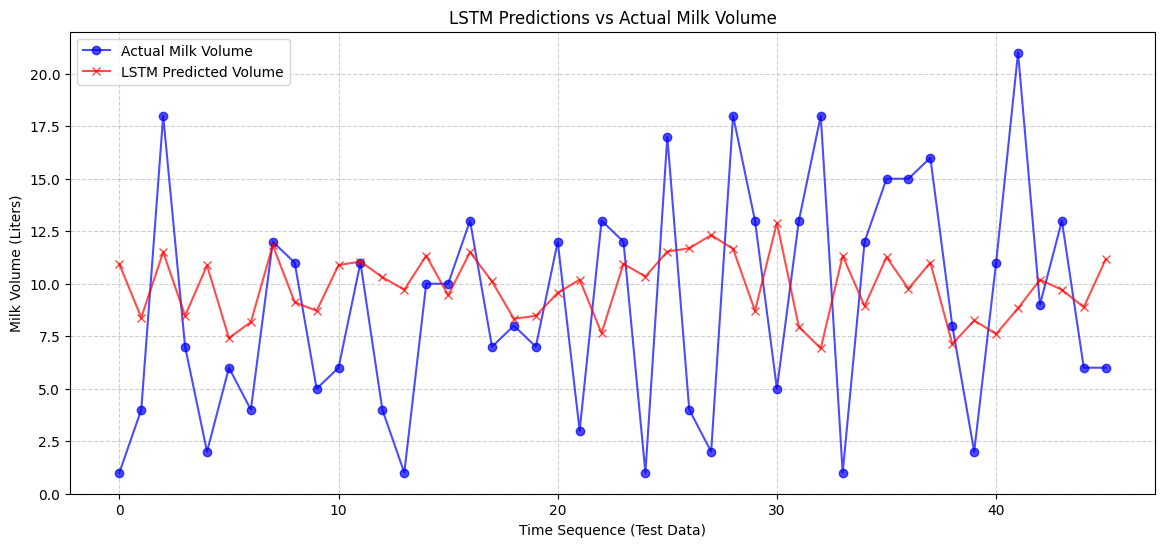

In [10]:
import matplotlib.pyplot as plt

# We plot only the first 100 sequences so the graph isn't too crowded
plt.figure(figsize=(14, 6))
plt.plot(y_true[:100], label="Actual Milk Volume", color='blue', marker='o', alpha=0.7)
plt.plot(y_pred[:100], label="LSTM Predicted Volume", color='red', marker='x', alpha=0.7)

plt.title("LSTM Predictions vs Actual Milk Volume")
plt.xlabel("Time Sequence (Test Data)")
plt.ylabel("Milk Volume (Liters)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()